# **Exploratory Data Analysis**

This notebook focuses on exploratory analysis of the processed MetroPT and hydraulic datasets. The goal is to identify important sensor patterns, understand variable relationships, and examine how different operating or degradation states are reflected in the available measurements.

Unlike Notebook 01, which focused on data loading and preprocessing, this notebook investigates the structure, variability, and relationships within the processed data in order to support later statistical testing and interpretation. Each dataset is analyzed separately, followed by a conceptual comparison between the two fluid-power systems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

metro = pd.read_csv('../data/processed/metro_cleaned.csv', parse_dates=['timestamp'])
hydraulics = pd.read_csv('../data/processed/hydraulics_features.csv')

print(f"MetroPT-3 dataset shape: {metro.shape}")
print(f"Hydraulic feature dataset shape: {hydraulics.shape}")

MetroPT-3 dataset shape: (1516948, 16)
Hydraulic feature dataset shape: (2205, 73)


## Analysis Roadmap

### MetroPT-3 Analysis
- Continuous sensor distributions
- Correlation structure
- Temporal patterns
- Binary/state signal frequencies
- Sensor behavior by operating state

### Hydraulic System Analysis
- Feature distributions
- Correlation structure
- Condition-stratified analysis
- Stable vs unstable cycles

### Cross-Dataset Comparison
- Structural properties
- Common sensor concepts
- Key differences

## MetroPT-3 Analysis

### Continuous sensor distributions

The seven continuous sensors measure pressure, temperature, and motor current on the air compressor. Their distributions reveal the typical operating ranges and suggest whether sensor values are concentrated around a baseline or spread across a wider dynamic range.

In [18]:
continuous_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']

Grouping by physical quantity type (pressure vs temperature/current):

#### Pressure-related sensors

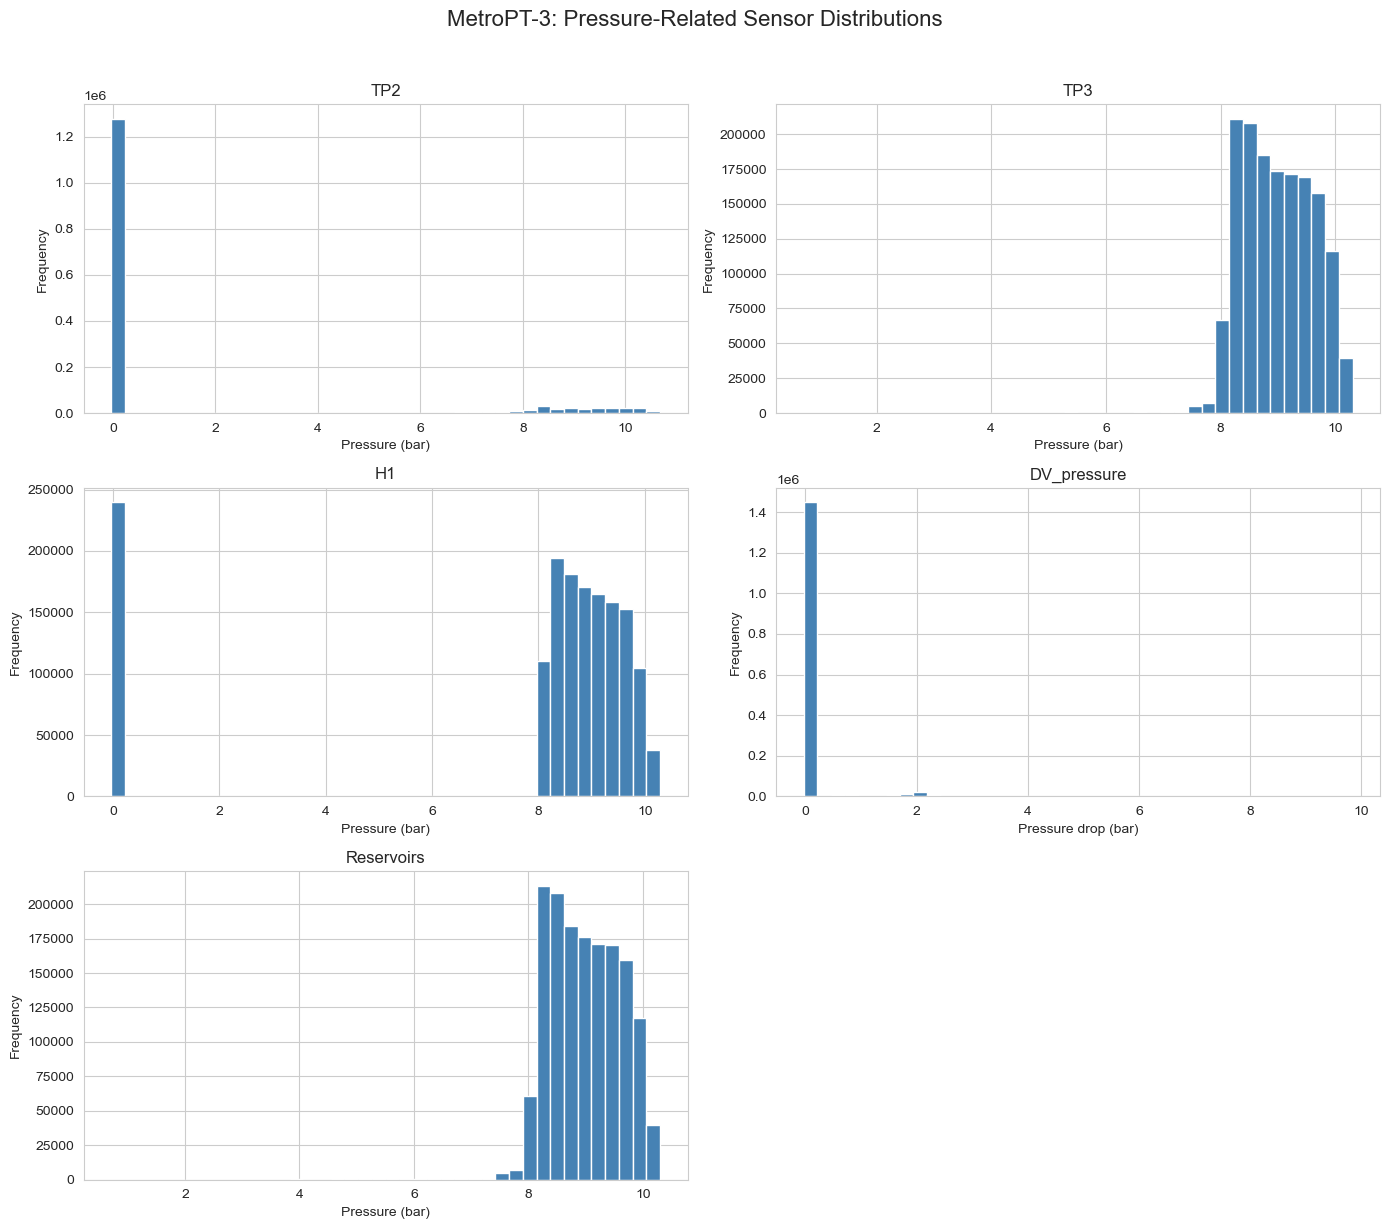

In [16]:
pressure_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(pressure_cols):
    axes[i].hist(metro[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Pressure (bar)' if col != 'DV_pressure' else 'Pressure drop (bar)')
    axes[i].set_ylabel('Frequency')

for j in range(len(pressure_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('MetroPT-3: Pressure-Related Sensor Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Observations**

`TP3` and `Reservoirs` have very similar distributions, concentrated mostly between about 8 and 10 bar. This is consistent with the dataset description, which states that downstream reservoir pressure should be close to the pneumatic panel pressure.

`TP2`, `H1`, and `DV_pressure` show strong mass near zero, together with a separate operating range at higher values. This suggests that these sensors are influenced by different machine states, rather than following one single continuous regime.

`DV_pressure` is especially sparse away from zero, which is consistent with the documentation that near-zero values indicate compressor operation under load.

Because `TP2`, `H1`, and `DV_pressure` contain a large mass of values near zero, their full histograms compress the active operating range and make it difficult to read. To visualize the non-zero behavior more clearly, values below 0.1 are filtered out in the plots below.

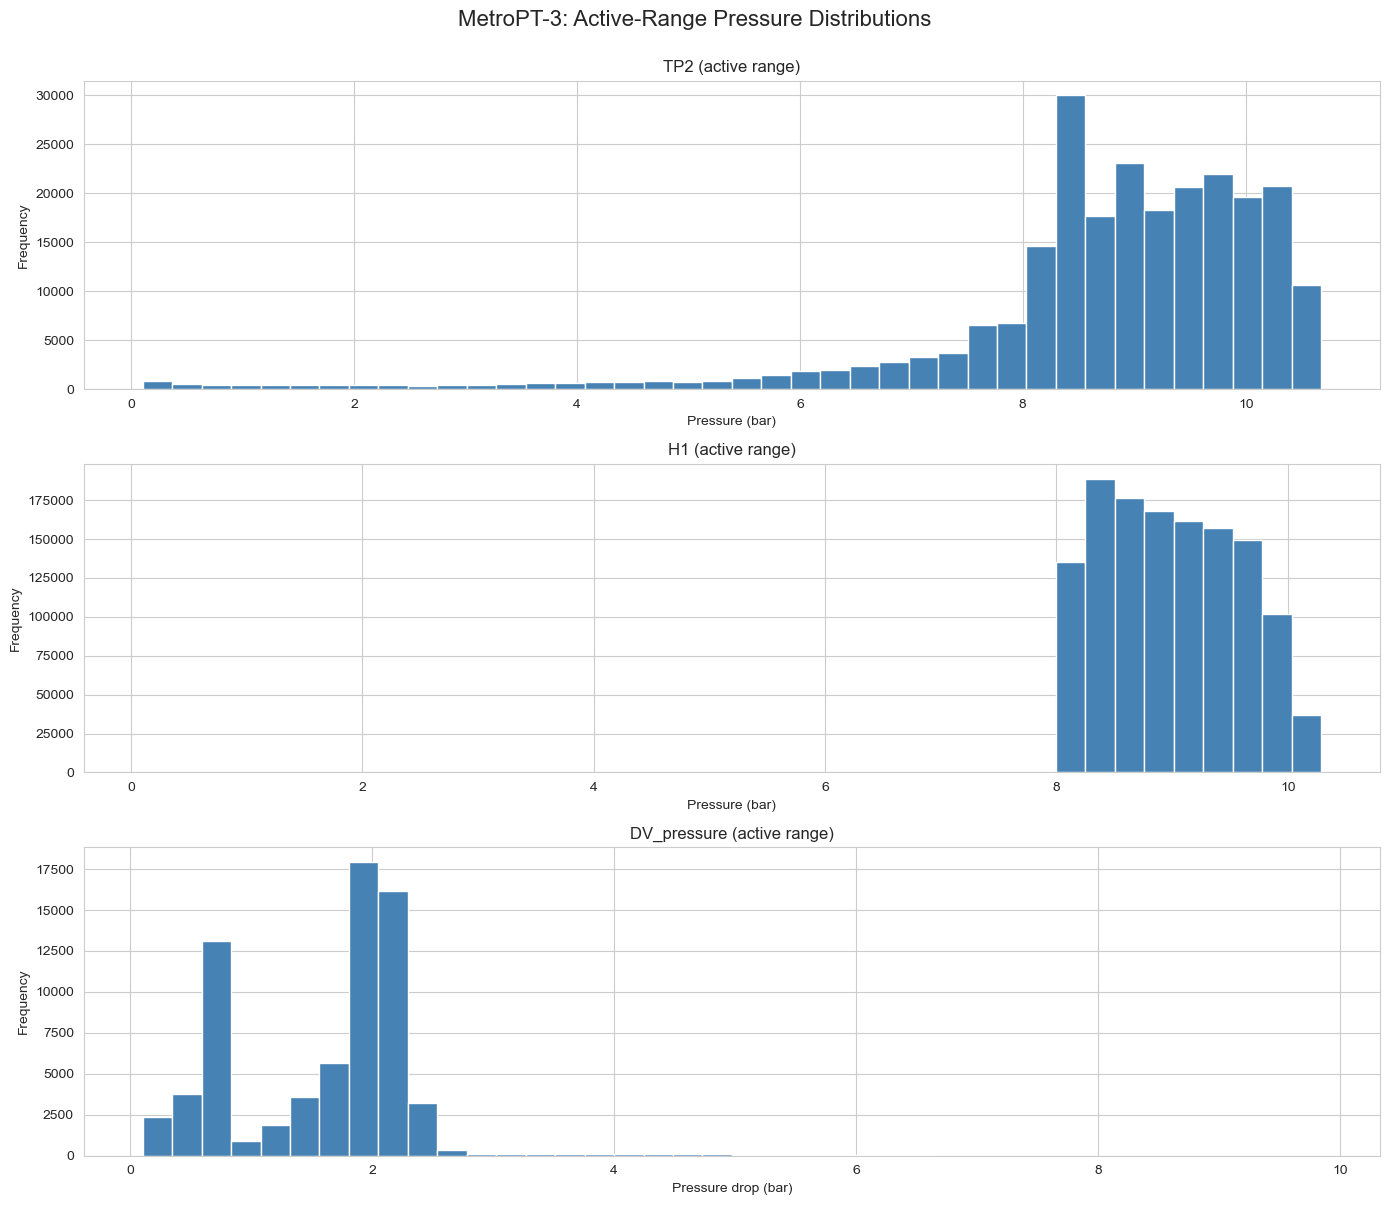

In [31]:
active_pressure_cols = ['TP2', 'H1', 'DV_pressure']

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, col in enumerate(active_pressure_cols):
    active_values = metro.loc[metro[col] > 0.1, col]
    axes[i].hist(active_values, bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} (active range)')
    axes[i].set_xlabel('Pressure (bar)' if col != 'DV_pressure' else 'Pressure drop (bar)')
    axes[i].set_ylabel('Frequency')

fig.suptitle('MetroPT-3: Active-Range Pressure Distributions', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

**Observations**

`TP2` (active range) has a broad active distribution, with most values concentrated roughly between 8 and 10.5 bar, but also a long lower-pressure tail. That suggests `TP2` reflects a wider range of active compressor states than `H1`.

`H1` (active range) is much more concentrated in the high-pressure region, mostly around 8–10 bar, with a relatively compact shape compared with `TP2`. That suggests a more stable active operating range.

`DV_pressure` (active range) is clearly different from the others. Its active values are concentrated mostly between about 0.5 and 2.5 bar, with a multi-peaked structure and a much smaller range than the other pressure variables. That suggests a different operational role and stronger dependence on specific machine states or events.

#### Temperature and motor current sensors

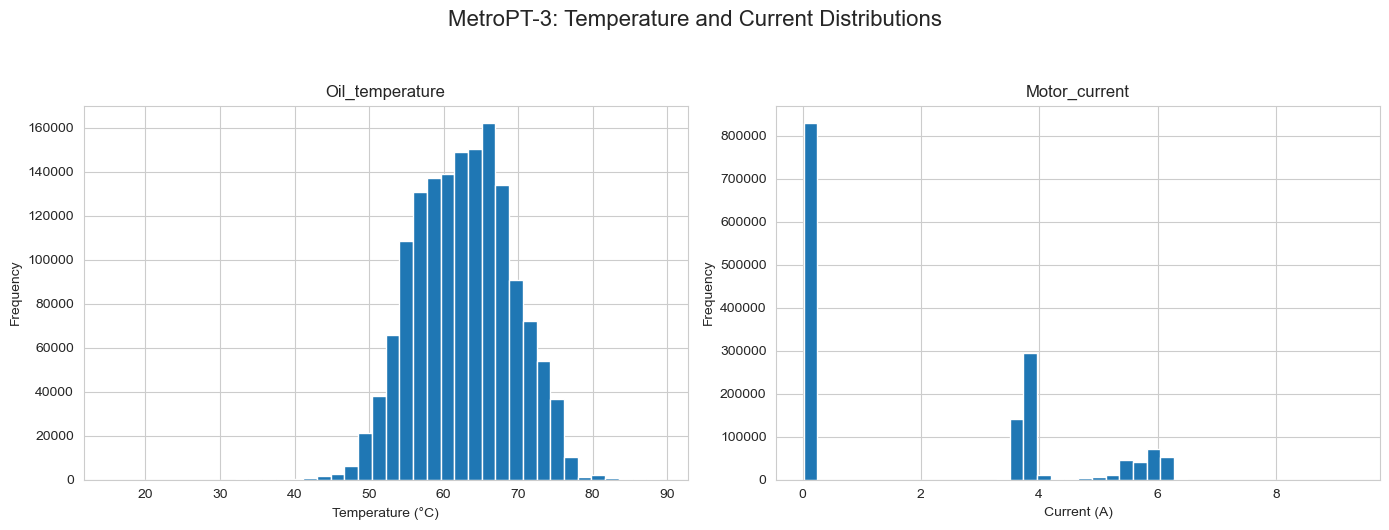

In [15]:
other_cols = ['Oil_temperature', 'Motor_current']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(metro['Oil_temperature'], bins=40)
axes[0].set_title('Oil_temperature')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')

axes[1].hist(metro['Motor_current'], bins=40)
axes[1].set_title('Motor_current')
axes[1].set_xlabel('Current (A)')
axes[1].set_ylabel('Frequency')

fig.suptitle('MetroPT-3: Temperature and Current Distributions', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

**Observations**

`Oil_temperature` is approximately symmetric and centered around 62°C, reflecting stable thermal conditions during operation. 

`Motor_current` shows a strongly multi-modal distribution, with a dominant inactive region near 0 A and additional operating clusters around roughly 4 A and 5–6 A. This is broadly consistent with the documented compressor operating modes. The 9 A peak may be too small to visually pick out at this bin count. Let's check it:

In [33]:
print(metro['Motor_current'].describe())
print((metro['Motor_current'] > 7).sum(), "samples above 7 A")

count    1.516948e+06
mean     2.050171e+00
std      2.302053e+00
min      2.000000e-02
25%      4.000000e-02
50%      4.500000e-02
75%      3.807500e+00
max      9.295000e+00
Name: Motor_current, dtype: float64
111 samples above 7 A


Seems values above 7 A appear only rarely and likely correspond to short startup-related events. This confirms `Motor_current` as a strong indicator of the compressor operating state: mostly idle, with brief active phases and rare startup peaks.

### Correlation structure

After examining the distributions of the continuous MetroPT variables, the next step is to study how these measurements relate to one another. For this purpose, Pearson correlation is used as a first summary of linear dependence between pairs of continuous sensor variables.

The Pearson correlation coefficient between two variables $X$ and $Y$ is defined as:

$$r_{X,Y} = \frac{\operatorname{Cov}(X,Y)}{\sigma_X \sigma_Y}$$

It takes values between $-1$ and $1$, where values close to $1$ indicate a strong positive linear relationship, values close to $-1$ indicate a strong negative linear relationship, and values near $0$ suggest little or no linear association.

Pearson correlation is appropriate here because the MetroPT continuous sensors measure related physical quantities such as pressure, temperature, and motor current, and the goal is to identify variables that move together during compressor operation. It should still be interpreted carefully: correlation reflects association rather than causation and mainly captures linear relationships.

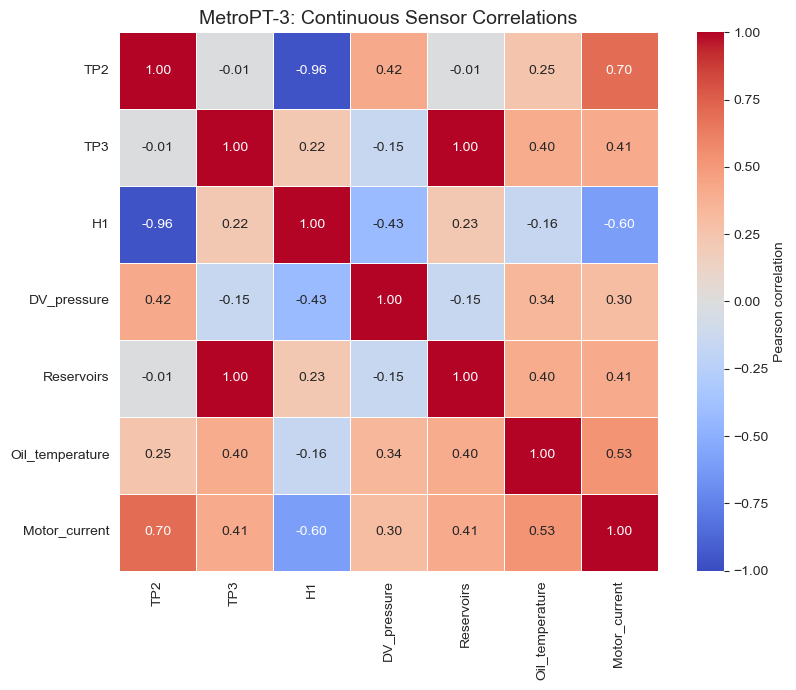

In [36]:
corr = metro[continuous_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'},
    ax=ax
)
ax.set_title('MetroPT-3: Continuous Sensor Correlations', fontsize=14)
plt.tight_layout()
plt.show()

**Observations**

The correlation structure reveals several meaningful patterns that are consistent with the physical behavior of the compressor system.

`TP3` and `Reservoirs` show an almost perfect positive correlation ($r \approx 1.00$), which agrees with the dataset documentation stating that reservoir pressure should remain close to the pneumatic panel pressure. In practice, these two variables appear to capture nearly the same downstream pressure regime.

`TP2` and `H1` are very strongly negatively correlated ($r \approx -0.96$). This suggests a tightly coupled inverse relationship between compressor pressure and the pressure-drop-related signal measured by `H1`, likely reflecting different phases of compressor operation.

`TP2` and `Motor_current` show a strong positive correlation ($r \approx 0.70$), while `H1` and `Motor_current` show a moderately strong negative correlation ($r \approx -0.60$). This is consistent with the idea that higher motor current is associated with active compression, during which `TP2` rises and `H1` tends to decrease.

`Oil_temperature` is moderately correlated with `Motor_current` ($r \approx 0.53$), which is consistent with heat generation during compressor activity. Its relationships with the pressure variables are weaker, suggesting that thermal behavior is influenced by operation, but less directly than pressure and current.

`DV_pressure` shows only weak to moderate correlations with the other continuous sensors. This supports the earlier interpretation that it behaves more like a specific discharge- or state-related signal than a direct continuous pressure measurement.

Overall, the correlation matrix suggests that the continuous sensors are strongly shaped by the compressor operating state, with clear grouping between variables related to active compression (`TP2`, `Motor_current`) and variables describing downstream pneumatic conditions (`TP3`, `Reservoirs`).